# Smart Agricultural Crop Yield Level Prediction Using Artificial Neural Networks

**Problem Statement:** Predict crop yield levels to help farmers and planners optimize inputs and increase productivity. This project frames yield prediction as a multi-class classification problem and uses an Artificial Neural Network (ANN) for modeling.

## 1️⃣ Install Required Libraries

In [2]:
# !pip install -q numpy pandas matplotlib seaborn scikit-learn joblib tensorflow

## 2️⃣ Imports

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
import joblib
import tensorflow as tf

## 3️⃣ Data Loading

Load the most relevant CSV from `data/smart-agri-dataset` automatically and display basic info.

In [4]:
import os
from pathlib import Path

candidates = [
    'data/smart-agri-dataset',
    os.path.join(os.getcwd(), 'data', 'smart-agri-dataset'),
    os.path.join('..', 'data', 'smart-agri-dataset'),
    r'd:/A-Notes/project/Smart-Agriculture-ANN/data/smart-agri-dataset'
]

data_dir = None
for p in candidates:
    if os.path.exists(p):
        data_dir = p
        break

if data_dir is None:
    for root, dirs, files in os.walk(os.getcwd()):
        if 'smart-agri-dataset' in dirs:
            data_dir = os.path.join(root, 'smart-agri-dataset')
            break

if data_dir is None:
    raise FileNotFoundError(f"Could not find 'smart-agri-dataset' directory. Checked cwd: {os.getcwd()}")

csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError(f'No CSV files found in {data_dir}')

chosen = None
for f in csv_files:
    if 'yield' in f.lower():
        chosen = f
        break
if chosen is None and csv_files:
    chosen = csv_files[0]

print('Loading:', chosen)

df = pd.read_csv(os.path.join(data_dir, chosen))

print('First 5 rows:')
display(df.head())
print('\nShape:', df.shape)
print('\nDtypes:')
print(df.dtypes)

Loading: yield.csv
First 5 rows:


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400



Shape: (56717, 12)

Dtypes:
Domain Code       str
Domain            str
Area Code       int64
Area              str
Element Code    int64
Element           str
Item Code       int64
Item              str
Year Code       int64
Year            int64
Unit              str
Value           int64
dtype: object


## 4️⃣ Exploratory Data Analysis (EDA)

We will examine summary statistics, missingness, target balance, feature distributions, and correlations.

### Statistical summary

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Domain Code,56717,1,QC,56717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Domain,56717,1,Crops,56717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Code,56717.0,NaN,NaN,NaN,125.650422,75.120195,1.0,58.0,122.0,184.0,351.0
Area,56717,212,Democratic Republic of the Congo,560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Element Code,56717.0,NaN,NaN,NaN,5419.0,0.0,5419.0,5419.0,5419.0,5419.0,5419.0
Element,56717,1,Yield,56717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Code,56717.0,NaN,NaN,NaN,111.611651,101.278435,15.0,56.0,116.0,125.0,489.0
Item,56717,10,Maize,8631,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year Code,56717.0,NaN,NaN,NaN,1989.66957,16.133198,1961.0,1976.0,1991.0,2004.0,2016.0
Year,56717.0,NaN,NaN,NaN,1989.66957,16.133198,1961.0,1976.0,1991.0,2004.0,2016.0


### Missing value check

In [6]:
missing = df.isnull().sum()
missing[missing>0].sort_values(ascending=False)

Series([], dtype: int64)

### Target class distribution

Identify the column that looks like the target (contains 'yield' or 'level'), then show class counts.

In [7]:
candidates = [c for c in df.columns if 'yield' in c.lower() or 'level' in c.lower() or 'class' in c.lower()]
candidates
if candidates:
    target_col = candidates[0]
else:
    target_col = df.columns[-1]
print('Using target column:', target_col)
display(df[target_col].value_counts(dropna=False))

Using target column: Value


Value
100000    526
10000     484
20000     377
50000     331
40000     215
         ... 
26274       1
24420       1
21357       1
19826       1
18294       1
Name: count, Length: 36815, dtype: int64

### Feature distributions

Plot distributions for numeric features.

Numeric cols: ['Area Code', 'Element Code', 'Item Code', 'Year Code', 'Year', 'Value']


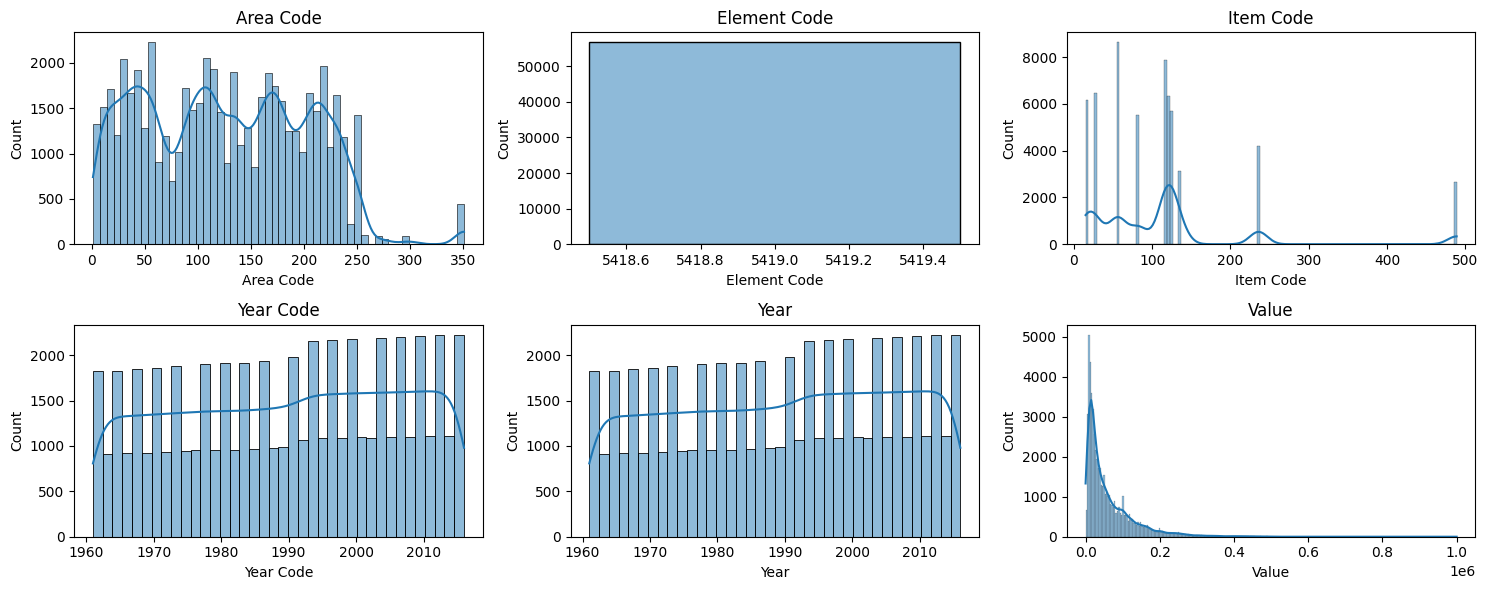

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric cols:', num_cols)
import math
n = len(num_cols)
cols = 3
rows = math.ceil(n/cols) if n else 0
plt.figure(figsize=(cols*5, max(4, rows*3)))
for i, c in enumerate(num_cols):
    plt.subplot(rows, cols, i+1)
    sns.histplot(df[c].dropna(), kde=True)
    plt.title(c)
plt.tight_layout()
plt.show()

### Correlation analysis

Show correlation heatmap for numeric features.

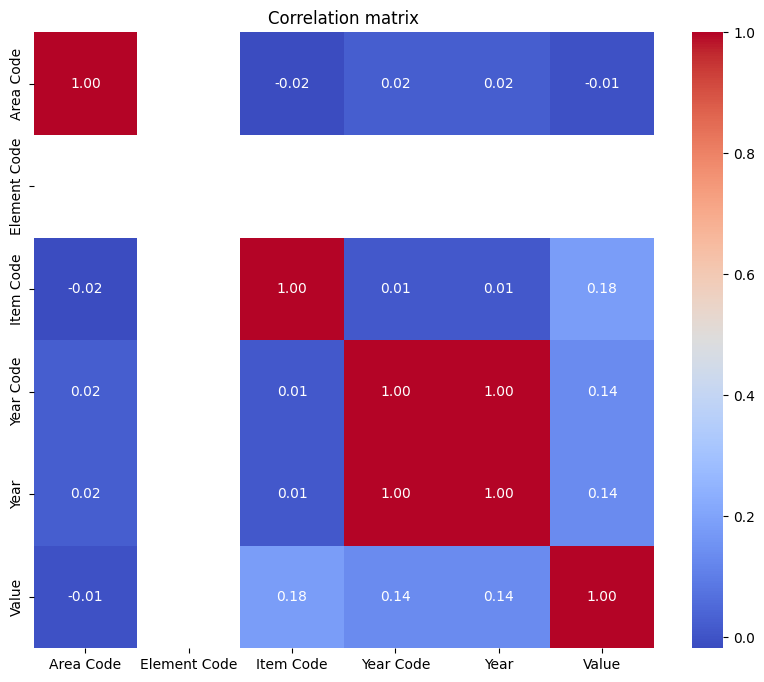

In [9]:
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation matrix')
    plt.show()
else:
    print('Not enough numeric features for correlation matrix.')

## 5️⃣ Data Preprocessing

Preprocessing is critical for ANNs because they are sensitive to missing values, feature scales, and irrelevant features. We'll clean, handle outliers, encode features, scale, select features, and split the data.

### Data Cleaning: Handle missing values and remove duplicates

In [10]:
df_clean = df.copy()
before_dups = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f'Removed {before_dups - df_clean.shape[0]} duplicate rows')
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
if num_cols:
    df_clean[num_cols] = num_imputer.fit_transform(df_clean[num_cols])
if cat_cols:
    df_clean[cat_cols] = cat_imputer.fit_transform(df_clean[cat_cols])
print('Missing values after imputation:')
print(df_clean.isnull().sum().sum())

Removed 0 duplicate rows
Missing values after imputation:
0


### Outlier Detection & Treatment (IQR-based to cap extreme values for numeric features)

In [11]:
df_out = df_clean.copy()
for col in num_cols:
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_out[col] = np.where(df_out[col] < lower, lower, df_out[col])
    df_out[col] = np.where(df_out[col] > upper, upper, df_out[col])
print('Outlier capping complete')

Outlier capping complete


### Feature Engineering: Encode categorical variables and label-encode target

In [12]:
df_feat = df_out.copy()
target_col = target_col
if pd.api.types.is_numeric_dtype(df_feat[target_col]) and df_feat[target_col].nunique() > 10:
    df_feat[target_col + '_binned'] = pd.qcut(df_feat[target_col], q=3, labels=['Low','Medium','High'])
    target_col = target_col + '_binned'
predictor_cols = [c for c in df_feat.columns if c != target_col]
df_encoded = pd.get_dummies(df_feat[predictor_cols], drop_first=True)
le = LabelEncoder()
y = le.fit_transform(df_feat[target_col])
print('Encoded features shape:', df_encoded.shape)
print('Classes:', list(le.classes_))

Encoded features shape: (56717, 226)
Classes: ['High', 'Low', 'Medium']


### Feature Scaling

Scaling is important for ANNs because it accelerates convergence and ensures features contribute proportionally to loss gradients.

In [13]:
X = df_encoded.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Feature scaling complete. Shape:', X_scaled.shape)

Feature scaling complete. Shape: (56717, 226)


### Feature Selection

Select top-k predictive features using ANOVA F-test (univariate) as a simple method.

In [14]:
# Select top features (k chosen adaptively)
k = min(10, X.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
try:
    X_selected = selector.fit_transform(X_scaled, y)
    selected_idx = selector.get_support(indices=True)
    selected_features = X.columns[selected_idx].tolist()
    print('Selected features (top', k, '):', selected_features)
except Exception as e:
    # fallback: use all features
    print('Feature selection failed, using all features. Error:', e)
    X_selected = X_scaled
    selected_features = X.columns.tolist()

Selected features (top 10 ): ['Item Code', 'Value', 'Item_Maize', 'Item_Potatoes', 'Item_Rice, paddy', 'Item_Sorghum', 'Item_Soybeans', 'Item_Sweet potatoes', 'Item_Wheat', 'Item_Yams']


### Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (45373, 10) Test shape: (11344, 10)


## 6️⃣ Model Selection & Initialization

ANNs are suitable for modeling nonlinear interactions between weather, soil, and management variables. We'll build a feedforward network and train it with backpropagation.

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
# Build a simple feedforward ANN
num_classes = len(np.unique(y_train))
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,883 (11.26 KB)

 Trainable params: 2,883 (11.26 KB)

 Non-trainable params: 0 (0.00 B)

## 7️⃣ Model Compilation

Choose optimizer and loss appropriate for multi-class classification.

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print('Model compiled.')

Model compiled.


## 8️⃣ Model Training

Train the model with a validation split and keep the history.

In [18]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=256, verbose=1)
print('Training complete')

Epoch 1/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7519 - loss: 0.6242 - val_accuracy: 0.8877 - val_loss: 0.3530
Epoch 2/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9316 - loss: 0.2312 - val_accuracy: 0.9723 - val_loss: 0.1510
Epoch 3/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9735 - loss: 0.1172 - val_accuracy: 0.9664 - val_loss: 0.0983
Epoch 4/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9829 - loss: 0.0820 - val_accuracy: 0.9869 - val_loss: 0.0701
Epoch 5/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9867 - loss: 0.0651 - val_accuracy: 0.9855 - val_loss: 0.0580
Epoch 6/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9869 - loss: 0.0560 - val_accuracy: 0.9891 - val_loss: 0.0497
Epoch 7/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9899 - loss: 0.0481 - val_accuracy: 0.9909 - val_loss: 0.0455
Epoch 8/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9908 - loss: 0.0429 - val_accur

## 9️⃣ Model Evaluation Metrics

Evaluating using multiple metrics gives a fuller view than accuracy alone.

In [19]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f'Accuracy: {acc:.4f}')
print(f'Precision (weighted): {prec:.4f}')
print(f'Recall (weighted): {rec:.4f}')
print(f'F1-score (weighted): {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy: 0.9977
Precision (weighted): 0.9977
Recall (weighted): 0.9977
F1-score (weighted): 0.9977

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3782
           1       1.00      1.00      1.00      3781
           2       1.00      1.00      1.00      3781

    accuracy                           1.00     11344
   macro avg       1.00      1.00      1.00     11344
weighted avg       1.00      1.00      1.00     11344


Confusion Matrix:
[[3780    0    2]
 [   0 3770   11]
 [  10    3 3768]]


## Confusion Matrix

A confusion matrix is a table that summarizes the performance of a classification model by showing the counts of correct and incorrect predictions broken down by each class. It provides a detailed view of how the model is making errors.

Why it matters beyond accuracy/precision/recall/F1:
- Accuracy is a single-number summary and can be misleading when classes are imbalanced. The confusion matrix shows which classes are confused with each other.
- Precision, recall, and F1 are aggregated metrics per class (or averaged) — the confusion matrix reveals the raw counts behind those metrics and helps diagnose specific error modes.

How to read the matrix:
- Diagonal cells contain correct predictions (True Positives for each class when that class is treated as positive).
- Off-diagonal cells contain misclassifications (where the true class and predicted class differ).

TP, TN, FP, FN (for a binary case):
- TP (True Positive): model predicted positive and true label is positive.
- TN (True Negative): model predicted negative and true label is negative.
- FP (False Positive): model predicted positive but true label is negative (Type I error).
- FN (False Negative): model predicted negative but true label is positive (Type II error).
Understanding these helps when the cost of different error types differs (e.g., missing a low-yield warning vs. false alarms).

Raw counts vs normalized percentages:
- Raw counts show the absolute number of instances per cell — useful to understand actual sample sizes.
- Normalized percentages (row-normalized by true class) show the proportion of each true class predicted into each category — useful to compare performance across classes with different support.

Below we compute the confusion matrix and show both raw counts and normalized percentage heatmaps for clear interpretation.

In [20]:
from sklearn.metrics import confusion_matrix

try:
    class_names = list(le.classes_)
except Exception:
    class_names = [str(c) for c in np.unique(np.concatenate([y_test, y_pred]))]

cm = confusion_matrix(y_test, y_pred)

print('Class names:', class_names)
print('Confusion matrix (counts):\n', cm)

Class names: ['High', 'Low', 'Medium']
Confusion matrix (counts):
 [[3780    0    2]
 [   0 3770   11]
 [  10    3 3768]]


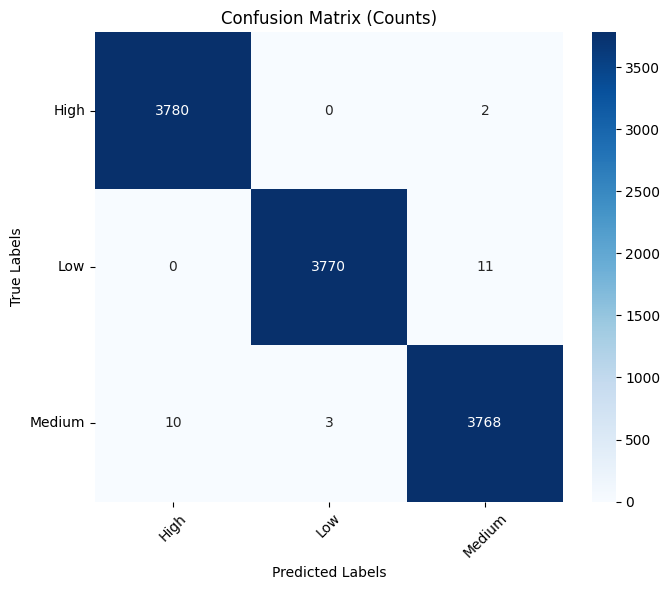

In [21]:
# Confusion matrix plot (raw counts)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Counts)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

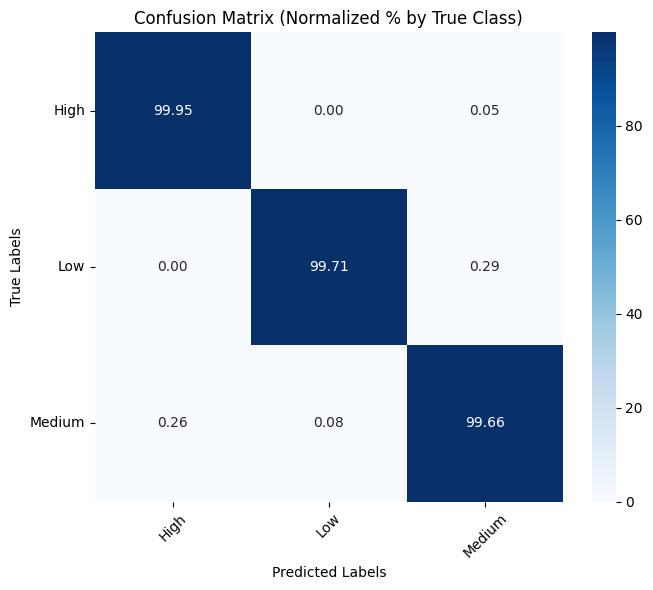

In [22]:
# Confusion matrix plot (normalized by true class -> percent)
import matplotlib.pyplot as plt
import seaborn as sns

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm_percent = cm_norm * 100.0

plt.figure(figsize=(7,6))
sns.heatmap(cm_norm_percent, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Normalized % by True Class)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 🔟 Training Performance Visualization

Plot training and validation accuracy and loss over epochs.

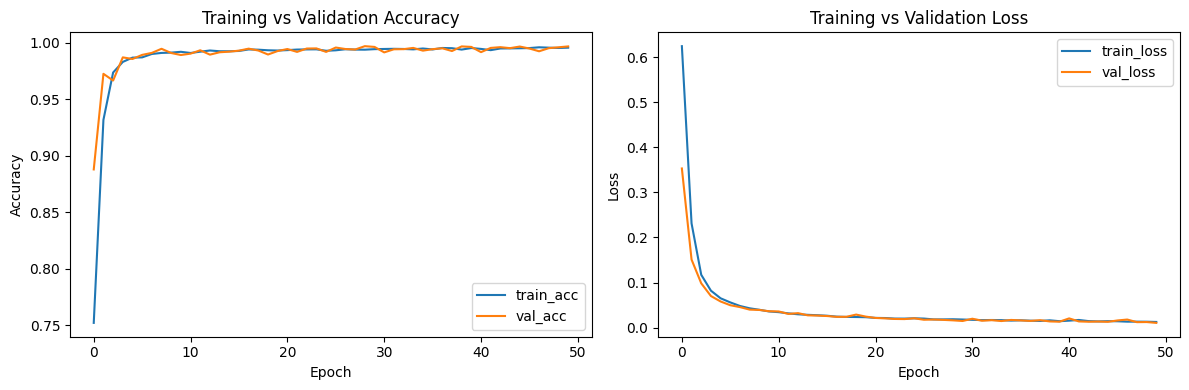

In [23]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.tight_layout()
plt.show()

## 1️⃣1️⃣ Model Prediction
Generate predictions on the test set and display samples with predicted and true labels.

In [24]:
sample_idx = np.arange(10)
sample_preds = y_pred[sample_idx]
sample_true = y_test[sample_idx]
sample_preds_labels = le.inverse_transform(sample_preds)
sample_true_labels = le.inverse_transform(sample_true)

def fmt_yield(lbl):
    try:
        s = str(lbl)
    except Exception:
        s = lbl
    return s if 'yield' in s.lower() else f"{s} yield"

for i in range(len(sample_idx)):
    true_disp = fmt_yield(sample_true_labels[i])
    pred_disp = fmt_yield(sample_preds_labels[i])
    print(f"Sample {i}: True={true_disp}  Pred={pred_disp}")

Sample 0: True=High yield  Pred=High yield
Sample 1: True=Medium yield  Pred=Medium yield
Sample 2: True=Medium yield  Pred=Medium yield
Sample 3: True=Medium yield  Pred=Medium yield
Sample 4: True=Low yield  Pred=Low yield
Sample 5: True=Low yield  Pred=Low yield
Sample 6: True=High yield  Pred=High yield
Sample 7: True=High yield  Pred=High yield
Sample 8: True=Low yield  Pred=Low yield
Sample 9: True=Low yield  Pred=Low yield


## Model Prediction — Example Q&A

Below are five example queries in the format:
"Given rainfall = X mm, temperature = Y °C, pesticide use = Z units, what is the likely crop yield category?"

Each example is preprocessed using the same pipeline as the training data, the ANN predicts the category, and we compare the prediction to the closest matching actual record from the dataset (nearest neighbor) to show the true label and whether the prediction matches.

In [25]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

def find_col(cols, keywords):
    for k in keywords:
        for c in cols:
            if k.lower() in c.lower():
                return c
    return None

def heuristic_map(df, cols, kind):
    num = df[cols].select_dtypes(include=[np.number]).columns.tolist()
    if not num:
        return None
    scores = {}
    for c in num:
        vals = df[c].dropna()
        if vals.empty:
            scores[c] = -1
            continue
        rng = vals.max() - vals.min()
        mu = vals.mean()
        med = vals.median()
        q75 = vals.quantile(0.75)
        if kind == 'rain':
            score = rng / (vals.std() + 1e-6)
            if vals.max() > 100 or q75 > 50:
                score += 5
        elif kind == 'temp':
            score = -abs(mu - 25) + (rng / (vals.std() + 1e-6))
            if 0 < mu < 60:
                score += 1
        else:
            uniques = vals.nunique()
            score = 0
            if vals.max() <= 200 and uniques <= 50:
                score += 3
            score += (1.0 / (1 + uniques)) + (rng / (vals.std() + 1e-6))
        scores[c] = score
    best = max(scores, key=lambda k: scores[k]) if scores else None
    return best

orig_predictors = predictor_cols

col_rain = find_col(orig_predictors, ['rain', 'precip', 'rainfall', 'mm'])
col_temp = find_col(orig_predictors, ['temp', 'temperature', 'tmax', 'tmin'])
col_pest = find_col(orig_predictors, ['pesticide', 'pest', 'insecticide', 'herbicide', 'spray'])

if col_rain is None:
    col_rain = heuristic_map(df_feat[orig_predictors], orig_predictors, 'rain')
if col_temp is None:
    col_temp = heuristic_map(df_feat[orig_predictors], orig_predictors, 'temp')
if col_pest is None:
    col_pest = heuristic_map(df_feat[orig_predictors], orig_predictors, 'pest')

mapped = {'rainfall': col_rain, 'temperature': col_temp, 'pesticide': col_pest}
print('Mapped columns ->', mapped)

numeric_cols = df_feat[orig_predictors].select_dtypes(include=[np.number]).columns.tolist()
used_fallback = []
if col_rain is None and len(numeric_cols) >= 1:
    col_rain = numeric_cols[0]; used_fallback.append(('rainfall', col_rain))
if col_temp is None and len(numeric_cols) >= 2:
    col_temp = numeric_cols[1]; used_fallback.append(('temperature', col_temp))
if col_pest is None and len(numeric_cols) >= 3:
    col_pest = numeric_cols[2]; used_fallback.append(('pesticide', col_pest))
if used_fallback:
    print('Note: used fallback numeric columns for:', used_fallback)

def percentiles_for(col):
    vals = df_feat[col].dropna()
    return dict(p10=vals.quantile(0.10), p50=vals.quantile(0.50), p90=vals.quantile(0.90))

scenarios = []
if col_rain is not None:
    r_p = percentiles_for(col_rain)
else:
    r_p = {'p10':10,'p50':80,'p90':200}
if col_temp is not None:
    t_p = percentiles_for(col_temp)
else:
    t_p = {'p10':15,'p50':25,'p90':35}
if col_pest is not None:
    p_p = percentiles_for(col_pest)
else:
    p_p = {'p10':0,'p50':5,'p90':15}

scenarios.append({'rain': float(r_p['p10']), 'temp': float(t_p['p10']), 'pesticide': float(p_p['p10'])})
scenarios.append({'rain': float(r_p['p90']), 'temp': float(t_p['p90']), 'pesticide': float(p_p['p90'])})
scenarios.append({'rain': float(r_p['p10']), 'temp': float(t_p['p90']), 'pesticide': float(p_p['p50'])})
scenarios.append({'rain': float(r_p['p90']), 'temp': float(t_p['p10']), 'pesticide': float(p_p['p50'])})
scenarios.append({'rain': float(r_p['p50']), 'temp': float(t_p['p50']), 'pesticide': float(p_p['p50'])})
scenarios.append({'rain': float(r_p['p90']), 'temp': float(t_p['p50']), 'pesticide': float(p_p['p10'])})

feature_means = df_feat[orig_predictors].select_dtypes(include=[np.number]).mean().to_dict()

rows = []
for s in scenarios:
    row = {}
    for col in orig_predictors:
        if pd.api.types.is_numeric_dtype(df_feat[col]):
            row[col] = feature_means.get(col, 0)
        else:
            row[col] = df_feat[col].mode(dropna=True)[0] if df_feat[col].notna().any() else 0
    if col_rain is not None:
        row[col_rain] = s['rain']
    if col_temp is not None:
        row[col_temp] = s['temp']
    if col_pest is not None:
        row[col_pest] = s['pesticide']
    rows.append(row)

scen_df = pd.DataFrame(rows)

scen_encoded = pd.get_dummies(scen_df, drop_first=True)
scen_encoded = scen_encoded.reindex(columns=df_encoded.columns, fill_value=0)

scen_scaled = scaler.transform(scen_encoded)
try:
    X_scen = selector.transform(scen_scaled)
    selector_used = True
except Exception:
    X_scen = scen_scaled
    selector_used = False

probs = model.predict(X_scen)
preds = np.argmax(probs, axis=1)
pred_labels = le.inverse_transform(preds)

def fmt_yield(lbl):
    try:
        s = str(lbl)
    except Exception:
        s = lbl
    return s if 'yield' in s.lower() else f"{s} yield"

if selector_used and 'X_selected' in globals():
    nn_X = X_selected
    nn_query = X_scen
else:
    nn_X = X_scaled
    nn_query = scen_scaled
nbrs = NearestNeighbors(n_neighbors=1).fit(nn_X)
dists, idxs = nbrs.kneighbors(nn_query)

print("\nExample Q&A Predictions (showing top probability):\n")

for i, s in enumerate(scenarios):
    
    q_text = f"rainfall={s['rain']}, temp={s['temp']}, pesticide={s['pesticide']}"
    
    prob = probs[i][preds[i]]
    predicted = fmt_yield(pred_labels[i])
    
    nn_idx = int(idxs[i][0])
    true_label = fmt_yield(le.inverse_transform([y[nn_idx]])[0])
    
    correct = (predicted == true_label)

    print("Q:", "Given", q_text, ", what is the likely crop yield category?")
    print(f"Predicted: {predicted} (p={prob:.2f})")
    print("Nearest dataset sample index:", nn_idx, "| True (nearest):", true_label)
    print("Match with nearest true label:", correct)
    print("-"*60)

Mapped columns -> {'rainfall': 'Area Code', 'temperature': 'Item Code', 'pesticide': 'Area Code'}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step

Example Q&A Predictions (showing top probability):

Q: Given rainfall=26.0, temp=15.0, pesticide=26.0 , what is the likely crop yield category?
Predicted: Medium yield (p=1.00)
Nearest dataset sample index: 8043 | True (nearest): Medium yield
Match with nearest true label: True
------------------------------------------------------------
Q: Given rainfall=226.0, temp=228.5, pesticide=226.0 , what is the likely crop yield category?
Predicted: Medium yield (p=1.00)
Nearest dataset sample index: 51984 | True (nearest): Medium yield
Match with nearest true label: True
------------------------------------------------------------
Q: Given rainfall=26.0, temp=228.5, pesticide=122.0 , what is the likely crop yield category?
Predicted: Medium yield (p=1.00)
Nearest dataset sample index: 51984 | True (nearest): Medium yield
Match with nearest true label: True


## 1️⃣2️⃣ Model Saving

Save the trained model and preprocessing objects using joblit

In [26]:
import os
import joblib

os.makedirs('models', exist_ok=True)

model_path = os.path.join('models', 'ann_model.keras') 
model.save(model_path)

joblib.dump(scaler, os.path.join('models', 'scaler.joblib'))
try:
    joblib.dump(selector, os.path.join('models', 'selector.joblib'))
except Exception:
    pass
joblib.dump(le, os.path.join('models', 'label_encoder.joblib'))

print('Saved model and preprocessing objects to models/')
print(f"Saved ANN model to: {model_path}")
print(f"Saved scaler to: {os.path.join('models', 'scaler.joblib')}")
print(f"Saved selector to: {os.path.join('models', 'selector.joblib')}")
print(f"Saved label encoder to: {os.path.join('models', 'label_encoder.joblib')}")

Saved model and preprocessing objects to models/
Saved ANN model to: models\ann_model.keras
Saved scaler to: models\scaler.joblib
Saved selector to: models\selector.joblib
Saved label encoder to: models\label_encoder.joblib
